In [2]:
import pandas as pd
gas_prices=pd.read_excel("data/raw/avgprice_annual.xlsx")
gas_prices.head()

,"Average Price (Cents/kilowatthour) by State by Provider, 1990-2020",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Year,State,Industry Sector Category,Residential,Commercial,Industrial,Transportation,Other,Total
1,2020,AK,Total Electric Industry,22.57,19.58,15.88,0,NaN,19.82
2,2020,AL,Total Electric Industry,12.58,11.55,5.87,0,NaN,9.84
3,2020,AR,Total Electric Industry,10.41,8.61,5.89,13.32,NaN,8.32
4,2020,AZ,Total Electric Industry,12.27,10.11,6.07,9.38,NaN,10.44


In [3]:
gas_prices=pd.read_excel("data/raw/avgprice_annual.xlsx", skiprows=1)
gas_prices.head()

,Year,State,Industry Sector Category,Residential,Commercial,Industrial,Transportation,Other,Total
0,2020,AK,Total Electric Industry,22.57,19.58,15.88,0.00,NaN,19.82
1,2020,AL,Total Electric Industry,12.58,11.55,5.87,0.00,NaN,9.84
2,2020,AR,Total Electric Industry,10.41,8.61,5.89,13.32,NaN,8.32
3,2020,AZ,Total Electric Industry,12.27,10.11,6.07,9.38,NaN,10.44
4,2020,CA,Total Electric Industry,20.45,17.53,14.27,10.07,NaN,18.00


In [5]:
gas_prices.shape

(4605, 9)

In [6]:
gas_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 4605 entries, 0 to 4604
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      4605 non-null   int64  
 1   State                     4605 non-null   str    
 2   Industry Sector Category  4605 non-null   str    
 3   Residential               4605 non-null   float64
 4   Commercial                4605 non-null   float64
 5   Industrial                4605 non-null   float64
 6   Transportation            2998 non-null   float64
 7   Other                     1607 non-null   float64
 8   Total                     4605 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 323.9 KB


In [8]:
is_us=gas_prices["State"]=="US"
is_2020=gas_prices["Year"]==2020
is_total=gas_prices["Industry Sector Category"]=="Total Electric Industry"
us_2020=gas_prices[is_us & is_2020 & is_total]
us_2020

,Year,State,Industry Sector Category,Residential,Commercial,Industrial,Transportation,Other,Total
51,2020,US,Total Electric Industry,13.15,10.59,6.67,9.9,NaN,10.59


In [9]:
us_over_time=gas_prices[is_us & is_total]
us_over_time

,Year,State,Industry Sector Category,Residential,Commercial,Industrial,Transportation,Other,Total
51,2020,US,Total Electric Industry,13.15,10.59,6.67,9.90,NaN,10.59
218,2019,US,Total Electric Industry,13.01,10.68,6.81,9.66,NaN,10.54
385,2018,US,Total Electric Industry,12.87,10.67,6.92,9.70,NaN,10.53
552,2017,US,Total Electric Industry,12.89,10.66,6.88,9.68,NaN,10.48
719,2016,US,Total Electric Industry,12.55,10.43,6.76,9.63,NaN,10.27
886,2015,US,Total Electric Industry,12.65,10.64,6.91,10.09,NaN,10.41
1053,2014,US,Total Electric Industry,12.52,10.74,7.10,10.45,NaN,10.44
1220,2013,US,Total Electric Industry,12.13,10.26,6.89,10.55,NaN,10.07
1384,2012,US,Total Electric Industry,11.88,10.09,6.67,10.21,NaN,9.84
1548,2011,US,Total Electric Industry,11.72,10.24,6.82,10.46,NaN,9.90


In [12]:
us_trend=us_over_time[["Year","Total"]] #double brackets for different columns
us_trend=us_trend.sort_values("Year")
us_trend = us_trend.reset_index(drop=True)
us_trend

,Year,Total
0,1990,6.57
1,1991,6.75
2,1992,6.82
3,1993,6.93
4,1994,6.91
5,1995,6.89
6,1996,6.86
7,1997,6.85
8,1998,6.74
9,1999,6.64


In [13]:
us_trend.describe()

,Year,Total
count,31.000000,31.000000
mean,2005.000000,8.481935
std,9.092121,1.593230
min,1990.000000,6.570000
25%,1997.500000,6.875000
50%,2005.000000,8.140000
75%,2012.500000,9.985000
max,2020.000000,10.590000


In [14]:
not_us=gas_prices["State"] != "US"
states_2020=gas_prices[is_2020 & is_total & not_us]
states_2020
states_2020.shape

(51, 9)

In [22]:
# each state has 1 row
most_expensive=states_2020[["State","Total"]].sort_values("Total",ascending=False)
most_expensive = most_expensive.reset_index(drop=True)
most_expensive.head(10)

,State,Total
0,HI,27.55
1,AK,19.82
2,CT,19.13
3,RI,18.54
4,MA,18.19
5,CA,18.00
6,NH,16.63
7,VT,16.33
8,NY,14.87
9,NJ,13.63


In [23]:
avg_by_year=gas_prices.groupby("Year")["Total"].mean() 
avg_by_year

Year
1990    6.475577
1991    6.648654
1992    6.737500
1993    6.882308
1994    6.891731
1995    6.911923
1996    6.869245
1997    6.702969
1998    6.637812
1999    7.913071
2000    6.189615
2001    6.602744
2002    6.582422
2003    6.601801
2004    6.597143
2005    7.227545
2006    8.006467
2007    8.356287
2008    8.964471
2009    8.808235
2010    8.863713
2011    9.074390
2012    8.997988
2013    9.207195
2014    9.514910
2015    9.463174
2016    9.321317
2017    9.530120
2018    9.720539
2019    9.751198
2020    9.737246
Name: Total, dtype: float64

In [26]:
year_stats=gas_prices.groupby("Year")["Total"].agg(["mean","min","max"])
year_stats

,mean,min,max
Year,,,
1990,6.475577,3.40,9.48
1991,6.648654,3.37,10.17
1992,6.737500,3.43,10.30
1993,6.882308,3.65,10.85
1994,6.891731,4.00,11.32
1995,6.911923,4.07,11.72
1996,6.869245,3.96,12.12
1997,6.702969,3.87,12.49
1998,6.637812,4.02,11.93


In [29]:
avg_by_state=gas_prices.groupby("State")["Total"].mean().sort_values(ascending=False)
avg_by_state.head(10)

State
HI    19.671613
AK    13.393871
CT    11.859098
VT    11.847097
MA    10.946202
NY    10.941679
NH    10.540687
RI    10.406183
CA     9.849389
NJ     9.709843
Name: Total, dtype: float64

In [31]:
clean=gas_prices[gas_prices["Industry Sector Category"]=="Total Electric Industry"]
clean_by_year=clean.groupby("Year")["Total"].mean()
clean_by_year.head()

Year
1990    6.475577
1991    6.648654
1992    6.737500
1993    6.882308
1994    6.891731
Name: Total, dtype: float64

In [32]:
atb=pd.ExcelFile("data/raw/2024_v3_Workbook.xlsx") #need to do this since sheet has multiple subsheets
atb.sheet_names

['Preface and Contents',
 'Financial Definitions',
 'Financial and CRP Inputs',
 'Land-Based Wind',
 'Fixed-Bottom Offshore Wind',
 'Floating Offshore Wind',
 'Distributed Wind',
 'Solar - Utility PV',
 'Solar - PV Dist. Comm',
 'Solar - PV Dist. Res',
 'Solar - CSP',
 'Geothermal',
 'Hydropower',
 'Nuclear',
 'Biopower',
 'Coal_FE',
 'Natural Gas_FE',
 'Natural Gas Fuel Cell_FE',
 'Coal_Retrofits',
 'Natural Gas_Retrofits',
 'Utility-Scale Battery Storage',
 'Commercial Battery Storage',
 'Residential Battery Storage',
 'Utility-Scale PV-Plus-Battery',
 'Pumped Storage Hydropower',
 'PSH One New Res',
 'WACC Calc',
 'Tax Credits',
 'Summary',
 'Summary_CAPEX',
 'Summary_CF',
 'Summary_FCR',
 'Summary_LCOE',
 'Summary_FOM',
 'Summary_VOM',
 'Summary_Fuel',
 'LCOE Range',
 'PV OCC',
 'Program Goals']

In [34]:
capex=pd.read_excel("data/raw/2024_v3_Workbook.xlsx", sheet_name="Summary_CAPEX")
capex.head()

,Key,FinancialCase,CostCase,CRPYears,Technology,TechDetail,DisplayName,2022,2023,2024,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,RA3CSSPClass2,R&D,Advanced,30,CSP,Class2,CSP - Class 2,7912.019603,7443.663803,6975.308003,...,3607.070669,3556.334076,3505.597482,3454.860888,3404.124294,3353.387700,3302.651107,3251.914513,3201.177919,3150.441325
1,RM3CSSPClass2,R&D,Moderate,30,CSP,Class2,CSP - Class 2,7912.019603,7570.505287,7228.990972,...,4781.260412,4745.019988,4708.779563,4672.539139,4636.298715,4600.058291,4563.817867,4527.577443,4491.337019,4455.096594
2,RC3CSSPClass2,R&D,Conservative,30,CSP,Class2,CSP - Class 2,7912.019603,7912.019603,7912.019603,...,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603
3,RA3CSSPClass3,R&D,Advanced,30,CSP,Class3,CSP - Class 3,7912.019603,7443.663803,6975.308003,...,3607.070669,3556.334076,3505.597482,3454.860888,3404.124294,3353.387700,3302.651107,3251.914513,3201.177919,3150.441325
4,RM3CSSPClass3,R&D,Moderate,30,CSP,Class3,CSP - Class 3,7912.019603,7570.505287,7228.990972,...,4781.260412,4745.019988,4708.779563,4672.539139,4636.298715,4600.058291,4563.817867,4527.577443,4491.337019,4455.096594


In [36]:
capex.shape
capex.columns.tolist()

['Key',
 'FinancialCase',
 'CostCase',
 'CRPYears',
 'Technology',
 'TechDetail',
 'DisplayName',
 2022,
 2023,
 2024,
 2025,
 2026,
 2027,
 2028,
 2029,
 2030,
 2031,
 2032,
 2033,
 2034,
 2035,
 2036,
 2037,
 2038,
 2039,
 2040,
 2041,
 2042,
 2043,
 2044,
 2045,
 2046,
 2047,
 2048,
 2049,
 2050]

In [38]:
sheets_needed=["Summary_CAPEX","Summary_CF","Summary_FCR","Summary_FOM", "Summary_VOM"]
atb_data=pd.read_excel("data/raw/2024_v3_Workbook.xlsx",sheet_name=sheets_needed)
for name in atb_data:
    print(name,"->", atb_data[name].shape)

Summary_CAPEX -> (526, 36)
Summary_CF -> (420, 36)
Summary_FCR -> (36, 36)
Summary_FOM -> (526, 36)
Summary_VOM -> (526, 36)


In [40]:
capex["FinancialCase"].unique()
capex["CRPYears"].unique()

array([30, 60, 45, '*', 100], dtype=object)

In [41]:
capex["FinancialCase"].value_counts()

FinancialCase
R&D    480
RD      46
Name: count, dtype: int64

In [42]:
# Screening Routine for future
col="FinancialCase"
print("Type:", capex[col].dtype)
print("Number of distinct values:", capex[col].nunique()) #nunique gives count of distinct values
print()
print(capex[col].value_counts(dropna=False)) #value_counts(dropna=False)) lists them with freq incl missing value
capex.isna().sum() #count of NaN in every column at once

Type: str
Number of distinct values: 2

FinancialCase
R&D    480
RD      46
Name: count, dtype: int64


Key               0
FinancialCase     0
CostCase          0
CRPYears          0
Technology        0
TechDetail        0
DisplayName       0
2022             31
2023             31
2024             31
2025             31
2026             31
2027             31
2028             31
2029             31
2030              4
2031              4
2032              4
2033              4
2034              4
2035              0
2036              0
2037              0
2038              0
2039              0
2040              0
2041              0
2042              0
2043              0
2044              0
2045              0
2046              0
2047              0
2048              0
2049              0
2050              0
dtype: int64

In [43]:
#LCOE functions live in src/lcoe.py. Pull them in here so we can use them.
import sys
sys.path.append("src")               # tell Python to also look inside the src folder

from lcoe import crf, fcr, lcoe       # grab our three functions by name

# test that it worked - should print about 0.0651
print(crf(0.05, 30))

39.78235103341901
0.06505143508027657


In [44]:
gas=pd.read_excel("data/raw/RNGWHHDm.xls",sheet_name="Data 1", skiprows=2)
gas.head()

,Date,Henry Hub Natural Gas Spot Price (Dollars per Million Btu)
0,1997-01-15,3.45
1,1997-02-15,2.15
2,1997-03-15,1.89
3,1997-04-15,2.03
4,1997-05-15,2.25


In [45]:
#rename second column with gas price for fun n simplicity
gas=gas.rename(columns={"Henry Hub Natural Gas Spot Price (Dollars per Million Btu)": "price_usd_mmbtu"})
gas.head()
        

,Date,price_usd_mmbtu
0,1997-01-15,3.45
1,1997-02-15,2.15
2,1997-03-15,1.89
3,1997-04-15,2.03
4,1997-05-15,2.25


In [47]:
gas["year"]=gas["Date"].dt.year #dt.year grabs just the year from the date as pandas reads the datess as real dates, hence we can use dt.year
gas.head()

,Date,price_usd_mmbtu,year
0,1997-01-15,3.45,1997
1,1997-02-15,2.15,1997
2,1997-03-15,1.89,1997
3,1997-04-15,2.03,1997
4,1997-05-15,2.25,1997


In [48]:
#average price per year
annual_gas=gas.groupby("year")["price_usd_mmbtu"].mean()
annual_gas #narrows annual_gas to a 1D series

year
1997    2.496667
1998    2.090833
1999    2.270000
2000    4.309167
2001    3.956667
2002    3.366667
2003    5.485833
2004    5.900000
2005    8.811667
2006    6.745000
2007    6.976667
2008    8.861667
2009    3.948333
2010    4.386667
2011    4.000000
2012    2.752500
2013    3.728333
2014    4.391667
2015    2.630000
2016    2.515000
2017    2.985833
2018    3.166667
2019    2.565833
2020    2.033333
2021    3.908333
2022    6.418333
2023    2.535833
2024    2.193333
2025    3.526667
2026    3.871667
Name: price_usd_mmbtu, dtype: float64

In [49]:
print("Lowest annual avg=", round(annual_gas.min(),2))
print("Highest annual avg", round(annual_gas.max(),2))
print("Most recent years:")
annual_gas.tail(6)

Lowest annual avg= 2.03
Highest annual avg 8.86
Most recent years:


year
2021    3.908333
2022    6.418333
2023    2.535833
2024    2.193333
2025    3.526667
2026    3.871667
Name: price_usd_mmbtu, dtype: float64

In [52]:
# Heat rate lives in the detailed technology sheet. Plan is to read the NaturalGas_FE sheet and look at its structure first.
gas_tech_raw= pd.read_excel("data/raw/2024_v3_Workbook.xlsx", sheet_name="Natural Gas_FE",header=None)
gas_tech_raw.shape

(361, 41)

In [54]:
gas_tech_raw.iloc[94:100,9:13] #heat-rate block in the spreadsheet, .iloc[rows,columns]

,9,10,11,12
94,Heat Rate (MMBtu/MWh),NG Combustion Turbine (F-Frame),Advanced,9.717
95,NaN,NG Combustion Turbine (F-Frame),Moderate,9.717
96,NaN,NG Combustion Turbine (F-Frame),Conservative,9.717
97,NaN,NG 2-on-1 Combined Cycle (F-Frame),Advanced,6.363
98,NaN,NG 2-on-1 Combined Cycle (F-Frame),Moderate,6.363
99,NaN,NG 2-on-1 Combined Cycle (F-Frame),Conservative,6.363


In [55]:
# Combined Cycle F-Frame, Moderate case: row 98, col 12
cc_heat_rate = gas_tech_raw.iloc[98, 12]

# Combustion Turbine F-Frame, Moderate case: row 95, col 12
ct_heat_rate = gas_tech_raw.iloc[95, 12]

print("Combined Cycle heat rate:", cc_heat_rate, "MMBtu/MWh")
print("Combustion Turbine heat rate:", ct_heat_rate, "MMBtu/MWh")

Combined Cycle heat rate: 6.363 MMBtu/MWh
Combustion Turbine heat rate: 9.717 MMBtu/MWh


In [58]:
# compute fuel ($/MWh) = heat_rate (MMBtu/MWh) x gas_price ($/MMBtu)
#Gas price scenarios
gas_low = 2.19    # 2024 avg - record low
gas_mid = 3.91    # 2021 avg - normal year
gas_high = 6.42   # 2022 avg - crisis spike

fuel_low = cc_heat_rate * gas_low
fuel_mid = cc_heat_rate * gas_mid
fuel_high = cc_heat_rate * gas_high

print("CC fuel cost - low: ", round(fuel_low, 2), "$/MWh")
print("CC fuel cost - mid: ", round(fuel_mid, 2), "$/MWh")
print("CC fuel cost - high:", round(fuel_high, 2), "$/MWh")


CC fuel cost - low:  13.93 $/MWh
CC fuel cost - mid:  24.88 $/MWh
CC fuel cost - high: 40.85 $/MWh


In [60]:
capex.head(3)

,Key,FinancialCase,CostCase,CRPYears,Technology,TechDetail,DisplayName,2022,2023,2024,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,RA3CSSPClass2,R&D,Advanced,30,CSP,Class2,CSP - Class 2,7912.019603,7443.663803,6975.308003,...,3607.070669,3556.334076,3505.597482,3454.860888,3404.124294,3353.387700,3302.651107,3251.914513,3201.177919,3150.441325
1,RM3CSSPClass2,R&D,Moderate,30,CSP,Class2,CSP - Class 2,7912.019603,7570.505287,7228.990972,...,4781.260412,4745.019988,4708.779563,4672.539139,4636.298715,4600.058291,4563.817867,4527.577443,4491.337019,4455.096594
2,RC3CSSPClass2,R&D,Conservative,30,CSP,Class2,CSP - Class 2,7912.019603,7912.019603,7912.019603,...,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603,7912.019603


In [65]:
#since data centers need 24/7 power, filter to get only firm-power technologies
def get_firm_rows(df):
    firm_techs=["NaturalGas_FE", "Nuclear", "Geothermal", "Coal_FE"]
    is_rnd=df["FinancialCase"].isin(["R&D", "RD"])
    is_moderate=df["CostCase"]=="Moderate"
    is_firm=df["Technology"].isin(firm_techs)
    return df[is_rnd & is_moderate & is_firm]
capex_firm=get_firm_rows(capex)
capex_firm[capex_firm["Technology"] == "NaturalGas_FE"][["DisplayName", "CRPYears", 2022]]

,DisplayName,CRPYears,2022
481,NG Combustion Turbine (F-Frame),30,1348.815136
484,NG 2-on-1 Combined Cycle (F-Frame),30,1499.253044
487,NG 2-on-1 Combined Cycle (H-Frame),30,1536.026755
490,NG 1-on-1 Combined Cycle (H-Frame),30,1763.020842
493,NG Fuel Cell,30,NaN
495,NG 2-on-1 Combined Cycle (F-Frame) 95% CCS,30,3071.830639
498,NG 2-on-1 Combined Cycle (H-Frame) 95% CCS,30,2924.178618
501,NG 1-on-1 Combined Cycle (H-Frame) 95% CCS,30,3419.620794
504,NG 2-on-1 Combined Cycle (F-Frame) 97% CCS,30,3117.073447
507,NG 2-on-1 Combined Cycle (H-Frame) 97% CCS,30,2964.518265


In [67]:
# Re-read FOM and VOM (these DO have gas rows, names match CAPEX)
fom_sheet = get_firm_rows(pd.read_excel("data/raw/2024_v3_Workbook.xlsx", sheet_name="Summary_FOM"))
vom_sheet = get_firm_rows(pd.read_excel("data/raw/2024_v3_Workbook.xlsx", sheet_name="Summary_VOM"))

def get_value(df, display_name):
    row = df[df["DisplayName"] == display_name]
    return row[2022].values[0]

plant = "NG 2-on-1 Combined Cycle (F-Frame)"

cc_capex = get_value(capex_firm, plant)
cc_fom   = get_value(fom_sheet, plant)
cc_vom   = get_value(vom_sheet, plant)

cc_cf = 0.87   # baseload combined-cycle, our assumption (see assumptions.md)

print("CAPEX:", round(cc_capex, 2), "$/kW")
print("CF:   ", cc_cf, "(our baseload assumption)")
print("FOM:  ", round(cc_fom, 2), "$/kW-yr")
print("VOM:  ", round(cc_vom, 2), "$/MWh")

CAPEX: 1499.25 $/kW
CF:    0.87 (our baseload assumption)
FOM:   34.5 $/kW-yr
VOM:   2.17 $/MWh


In [68]:
# Finance assumptions - real WACC and 30-yr cost recovery period
wacc = 0.041          
crp = 30
pff = 1.0           

# Fuel cost per scenario = heat_rate x gas_price (computed earlier)
fuel_low  = cc_heat_rate * 2.19    # 2024 low
fuel_mid  = cc_heat_rate * 3.91    # 2021 mid
fuel_high = cc_heat_rate * 6.42    # 2022 high

lcoe_low  = lcoe(wacc, crp, pff, cc_capex, cc_fom, cc_cf, cc_vom, fuel_low)
lcoe_mid  = lcoe(wacc, crp, pff, cc_capex, cc_fom, cc_cf, cc_vom, fuel_mid)
lcoe_high = lcoe(wacc, crp, pff, cc_capex, cc_fom, cc_cf, cc_vom, fuel_high)

print("Gas Combined Cycle LCOE:")
print("  Low gas ($2.19): ", round(lcoe_low, 2), "$/MWh")
print("  Mid gas ($3.91): ", round(lcoe_mid, 2), "$/MWh")
print("  High gas ($6.42):", round(lcoe_high, 2), "$/MWh")

Gas Combined Cycle LCOE:
  Low gas ($2.19):  32.15 $/MWh
  Mid gas ($3.91):  43.09 $/MWh
  High gas ($6.42): 59.06 $/MWh


In [71]:
# assemble LCOE for ALL firm-power technologies
# reusable value-getter (uses 2030 fallback if 2022 is missing) 
def get_val(df, name, year=2022):
    row = df[df["DisplayName"] == name]
    v = row[year].values[0]
    if pd.isna(v):
        return row[2030].values[0]   # fallback for nuclear
    return v
    
def load_firm(sheet):
    return get_firm_rows(pd.read_excel("data/raw/2024_v3_Workbook.xlsx", sheet_name=sheet))

capex_s = load_firm("Summary_CAPEX")
fom_s   = load_firm("Summary_FOM")
vom_s   = load_firm("Summary_VOM")
cf_s    = load_firm("Summary_CF")
results = []

# 1. GEOTHERMAL (Hydro/Flash) - real 2022, CF in sheet, NO fuel 
name = "Geothermal - Hydro / Flash"
geo_lcoe = lcoe(
    wacc, crp, pff,
    capex=get_val(capex_s, name),
    fom=get_val(fom_s, name),
    cf=get_val(cf_s, name),          # 0.9, from the sheet
    vom=get_val(vom_s, name),        # 0
    fuel=0,                           # earth's heat is free - NO fuel cost
)
results.append(["Geothermal (Hydro/Flash)", round(geo_lcoe, 2), "2022"])
print("Geothermal:", round(geo_lcoe, 2), "$/MWh")

# 2. NUCLEAR (Large) - 2022 missing, use 2030 fallback 
name = "Nuclear - Large"
nuc_lcoe = lcoe(
    wacc, crp, pff,
    capex=get_val(capex_s, name),    # get_val auto-falls-back to 2030
    fom=get_val(fom_s, name),
    cf=get_val(cf_s, name),          # 0.93
    vom=get_val(vom_s, name),        # ~2.8 (fuel is bundled in here)
    fuel=0,                           # nuclear fuel bundled into VOM - don't double count
)
results.append(["Nuclear (Large)", round(nuc_lcoe, 2), "2030 (fallback)"])
print("Nuclear:", round(nuc_lcoe, 2), "$/MWh  [uses 2030 costs]")

# 3. COAL (new) - fossil, so CF + heat rate are my assumptions 
# Coal heat rate ~8.8 MMBtu/MWh. Coal price ~$2/MMBtu (much cheaper than gas).
coal_heat_rate = 8.8       # MMBtu/MWh, typical new coal
coal_price = 2.0           # $/MMBtu, typical US coal (cheaper than gas per unit)
coal_fuel = coal_heat_rate * coal_price

name = "Coal-new"
coal_lcoe = lcoe(
    wacc, crp, pff,
    capex=get_val(capex_s, name),
    fom=get_val(fom_s, name),
    cf=0.85,                          
    vom=get_val(vom_s, name),
    fuel=coal_fuel,
)
results.append(["Coal (new)", round(coal_lcoe, 2), "2022"])
print("Coal:", round(coal_lcoe, 2), "$/MWh")

#4. GAS - add the three scenarios we already computed
results.append(["Gas CC - low gas ($2.19)",  round(lcoe_low, 2),  "2022"])
results.append(["Gas CC - mid gas ($3.91)",  round(lcoe_mid, 2),  "2022"])
results.append(["Gas CC - high gas ($6.42)", round(lcoe_high, 2), "2022"])

comparison = pd.DataFrame(results, columns=["Technology", "LCOE ($/MWh)", "Cost Year"])
comparison = comparison.sort_values("LCOE ($/MWh)").reset_index(drop=True)
comparison

Geothermal: 68.92 $/MWh
Nuclear: 79.0 $/MWh  [uses 2030 costs]
Coal: 70.58 $/MWh


,Technology,LCOE ($/MWh),Cost Year
0,Gas CC - low gas ($2.19),32.15,2022
1,Gas CC - mid gas ($3.91),43.09,2022
2,Gas CC - high gas ($6.42),59.06,2022
3,Geothermal (Hydro/Flash),68.92,2022
4,Coal (new),70.58,2022
5,Nuclear (Large),79.00,2030 (fallback)


In [72]:
comparison.to_csv("data/processed/firm_lcoe_comparison.csv", index=False)
print("Saved comparison table")

Saved comparison table


In [78]:
# gas+CCS LCOE and the 45Q verdict

# LCOE of the gas+CCS plant (before credit) ----
plant_ccs = "NG 2-on-1 Combined Cycle (F-Frame) 95% CCS"

ccs_capex = get_val(capex_s, plant_ccs)     
ccs_fom   = get_val(fom_s, plant_ccs)

# VOM row for F-Frame 95% CCS is MISSING in this workbook copy.
# Stand-in: F-Frame 97% CCS VOM (near-identical plant).
ccs_vom = get_val(vom_s, "NG 2-on-1 Combined Cycle (F-Frame) 97% CCS")

ccs_cf = 0.87                              

# CCS plant burns MORE gas per MWh (energy penalty: 7.16 vs 6.363)
fuel_ccs_low  = ccs_heat_rate * 2.19
fuel_ccs_mid  = ccs_heat_rate * 3.91
fuel_ccs_high = ccs_heat_rate * 6.42

lcoe_ccs_low  = lcoe(wacc, crp, pff, ccs_capex, ccs_fom, ccs_cf, ccs_vom, fuel_ccs_low)
lcoe_ccs_mid  = lcoe(wacc, crp, pff, ccs_capex, ccs_fom, ccs_cf, ccs_vom, fuel_ccs_mid)
lcoe_ccs_high = lcoe(wacc, crp, pff, ccs_capex, ccs_fom, ccs_cf, ccs_vom, fuel_ccs_high)

print("Gas+CCS LCOE BEFORE credit:")
print("  low: ", round(lcoe_ccs_low, 2), "$/MWh")
print("  mid: ", round(lcoe_ccs_mid, 2), "$/MWh")
print("  high:", round(lcoe_ccs_high, 2), "$/MWh")
print()

# apply the 45Q credit and build the verdict table ----
# credit_per_mwh (~30.64) computed earlier: captured CO2 x $85/tonne
ccs_net_low  = lcoe_ccs_low  - credit_per_mwh
ccs_net_mid  = lcoe_ccs_mid  - credit_per_mwh
ccs_net_high = lcoe_ccs_high - credit_per_mwh

verdict = pd.DataFrame({
    "Gas scenario": ["Low ($2.19)", "Mid ($3.91)", "High ($6.42)"],
    "Plain gas":    [round(lcoe_low, 2),      round(lcoe_mid, 2),      round(lcoe_high, 2)],
    "CCS before":   [round(lcoe_ccs_low, 2),  round(lcoe_ccs_mid, 2),  round(lcoe_ccs_high, 2)],
    "CCS after 45Q":[round(ccs_net_low, 2),   round(ccs_net_mid, 2),   round(ccs_net_high, 2)],
})
verdict["CCS premium after credit"] = verdict["CCS after 45Q"] - verdict["Plain gas"]

print(verdict.to_string(index=False))
print()

verdict.to_csv("data/processed/ccs_45q_verdict.csv", index=False)
print("Saved ccs_45q_verdict.csv")

Gas+CCS LCOE BEFORE credit:
  low:  53.76 $/MWh
  mid:  66.08 $/MWh
  high: 84.05 $/MWh

Gas scenario  Plain gas  CCS before  CCS after 45Q  CCS premium after credit
 Low ($2.19)      32.15       53.76          23.12                     -9.03
 Mid ($3.91)      43.09       66.08          35.43                     -7.66
High ($6.42)      59.06       84.05          53.40                     -5.66

Saved ccs_45q_verdict.csv


Gas+CCS LCOE BEFORE credit:
  low:  53.76 $/MWh
  mid:  66.08 $/MWh
  high: 84.05 $/MWh

Gas scenario  Plain gas  CCS before  CCS after 45Q  CCS premium after credit
 Low ($2.19)      32.15       53.76          23.12                     -9.03
 Mid ($3.91)      43.09       66.08          35.43                     -7.66
High ($6.42)      59.06       84.05          53.40                     -5.66

Saved ccs_45q_verdict.csv


In [79]:
# break-even sensitivity analysis including transport and storage (T&S) cost assumptions and scenario for CO2

# sweep T&S cost from $0 to $30 per tonne, in $5 steps
for t in range(0, 31, 5):
    ts_per_mwh = co2_captured * t
    premium = (ccs_net_mid + ts_per_mwh) - lcoe_mid
    print("T&S $", t, "/tonne  ->  premium:", round(premium, 2), "$/MWh")

T&S $ 0 /tonne  ->  premium: -7.66 $/MWh
T&S $ 5 /tonne  ->  premium: -5.86 $/MWh
T&S $ 10 /tonne  ->  premium: -4.05 $/MWh
T&S $ 15 /tonne  ->  premium: -2.25 $/MWh
T&S $ 20 /tonne  ->  premium: -0.45 $/MWh
T&S $ 25 /tonne  ->  premium: 1.35 $/MWh
T&S $ 30 /tonne  ->  premium: 3.16 $/MWh


In [82]:
import matplotlib.pyplot as plt

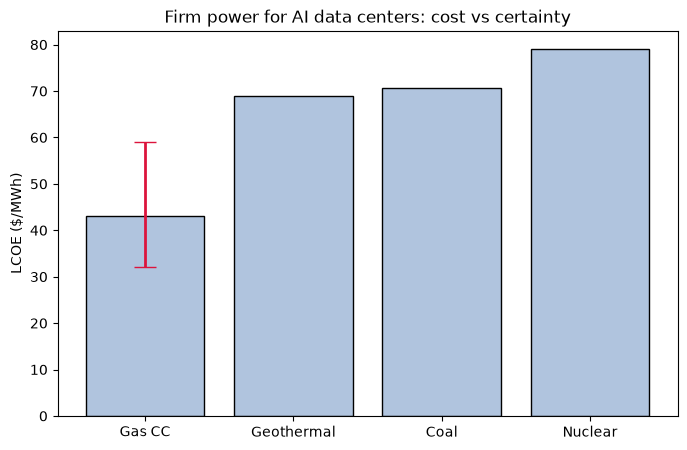

In [83]:
techs      = ["Gas CC", "Geothermal", "Coal", "Nuclear"]
lcoe_vals  = [43.09, 68.92, 70.58, 79.00]   # mid / flat values
gas_lo, gas_hi = 32.15, 59.06                

fig, ax = plt.subplots(figsize=(8, 5))       

ax.bar(techs, lcoe_vals, color="lightsteelblue", edgecolor="black")
ax.errorbar(
    x=0, y=43.09,
    yerr=[[43.09 - gas_lo], [gas_hi - 43.09]],  # [down], [up]
    fmt="none", color="crimson", capsize=8, linewidth=2,
)
ax.set_ylabel("LCOE ($/MWh)")
ax.set_title("Firm power for AI data centers: cost vs certainty")

plt.show()

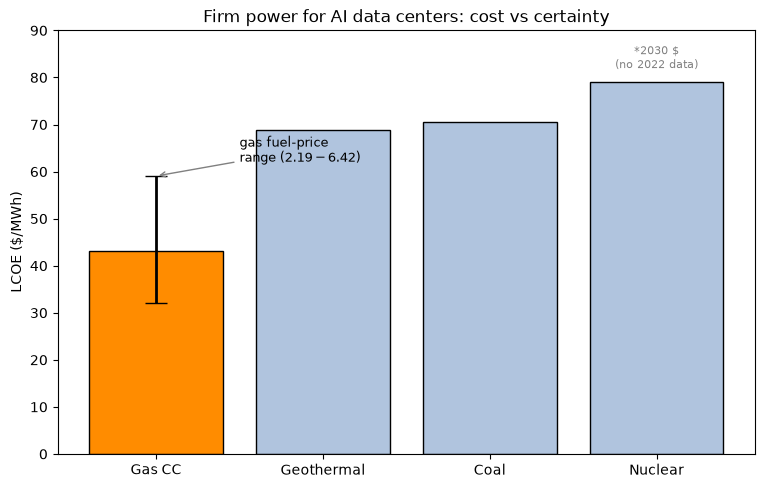

In [84]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# color-code: gas = fuel-exposed (orange), others = flat/certain (steel blue)
bar_colors = ["darkorange", "lightsteelblue", "lightsteelblue", "lightsteelblue"]
ax.bar(techs, lcoe_vals, color=bar_colors, edgecolor="black")

ax.errorbar(
    x=0, y=43.09,
    yerr=[[43.09 - gas_lo], [gas_hi - 43.09]],
    fmt="none", color="black", capsize=8, linewidth=2,
)

ax.annotate("gas fuel-price\nrange ($2.19-$6.42)",
            xy=(0, gas_hi), xytext=(0.5, 62),
            fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="gray"))

# flag nuclear's different cost year since data only avail starting 2030
ax.annotate("*2030 $\n(no 2022 data)",
            xy=(3, 79), xytext=(3, 82),
            fontsize=8, ha="center", color="gray")

ax.set_ylabel("LCOE ($/MWh)")
ax.set_title("Firm power for AI data centers: cost vs certainty")
ax.set_ylim(0, 90)  

plt.show()

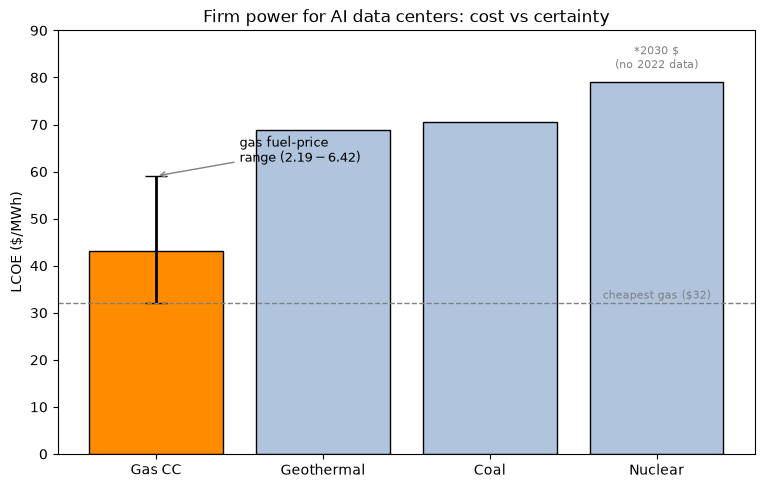

In [89]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bar_colors = ["darkorange", "lightsteelblue", "lightsteelblue", "lightsteelblue"]
ax.bar(techs, lcoe_vals, color=bar_colors, edgecolor="black")

ax.errorbar(
    x=0, y=43.09,
    yerr=[[43.09 - gas_lo], [gas_hi - 43.09]],
    fmt="none", color="black", capsize=8, linewidth=2,
)

ax.annotate("gas fuel-price\nrange ($2.19-$6.42)",
            xy=(0, gas_hi), xytext=(0.5, 62),
            fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.annotate("*2030 $\n(no 2022 data)",
            xy=(3, 79), xytext=(3, 82),
            fontsize=8, ha="center", color="gray")

# reference line at cheapest possible power (low-gas)
ax.axhline(y=32.15, color="gray", linestyle="--", linewidth=1)
ax.annotate("cheapest gas ($32)", xy=(3, 33), fontsize=8, color="gray", ha="center")

ax.set_ylabel("LCOE ($/MWh)")
ax.set_title("Firm power for AI data centers: cost vs certainty")
ax.set_ylim(0, 90)

plt.savefig("figures/firm_power_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

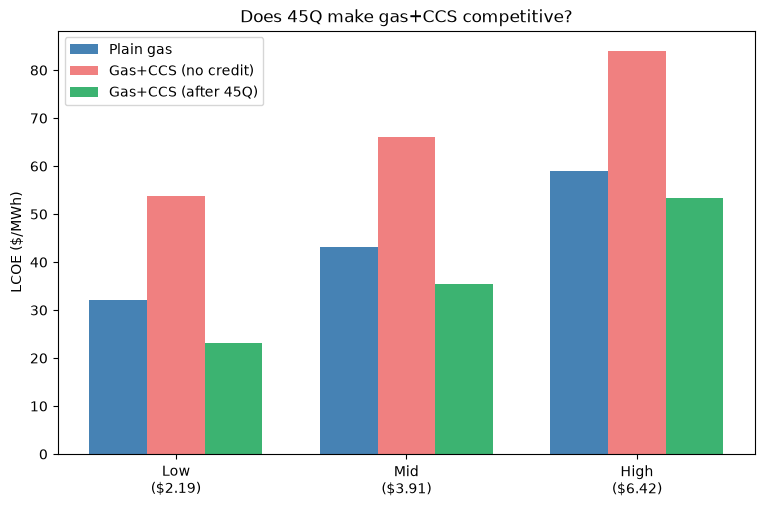

In [90]:
import numpy as np

scenarios = ["Low\n($2.19)", "Mid\n($3.91)", "High\n($6.42)"]
plain   = [32.15, 43.09, 59.06]
ccs_bef = [53.76, 66.08, 84.05]
ccs_aft = [23.12, 35.43, 53.40]

x = np.arange(len(scenarios))   # group centers: 0, 1, 2
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(x - width, plain,   width, label="Plain gas",            color="steelblue")
ax.bar(x,         ccs_bef, width, label="Gas+CCS (no credit)",  color="lightcoral")
ax.bar(x + width, ccs_aft, width, label="Gas+CCS (after 45Q)",  color="mediumseagreen")

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("LCOE ($/MWh)")
ax.set_title("Does 45Q make gas+CCS competitive?")
ax.legend()

plt.savefig("figures/ccs_45q_verdict.png", dpi=150, bbox_inches="tight")
plt.show()

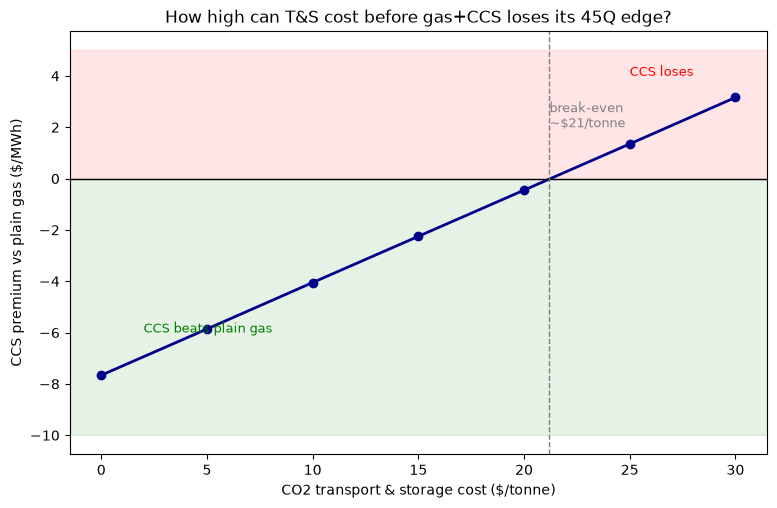

In [91]:
# T&S break-even chart
ts_costs = [0, 5, 10, 15, 20, 25, 30]
premiums = [-7.66, -5.86, -4.05, -2.25, -0.45, 1.35, 3.16]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ts_costs, premiums, marker="o", color="darkblue", linewidth=2)

ax.axhline(y=0, color="black", linewidth=1)

ax.axhspan(-10, 0, alpha=0.1, color="green")   # CCS wins zone
ax.axhspan(0, 5, alpha=0.1, color="red")        # CCS loses zone

ax.axvline(x=21.2, color="gray", linestyle="--", linewidth=1)
ax.annotate("break-even\n~$21/tonne", xy=(21.2, 2), fontsize=9, color="gray")

ax.annotate("CCS beats plain gas", xy=(2, -6), fontsize=9, color="green")
ax.annotate("CCS loses", xy=(25, 4), fontsize=9, color="red")

ax.set_xlabel("CO2 transport & storage cost ($/tonne)")
ax.set_ylabel("CCS premium vs plain gas ($/MWh)")
ax.set_title("How high can T&S cost before gas+CCS loses its 45Q edge?")

plt.savefig("figures/ts_breakeven.png", dpi=150, bbox_inches="tight")
plt.show()